 Personalized recommendation system 


In [13]:
import pandas as pd
import numpy as np
import re
import random
import time
import collections
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.linestyle': '--',
    'grid.alpha': 0.4,
    'axes.linewidth': 0.8,
})

In [14]:
class ITCareerAdvisorFinal:
    def __init__(self):
        self.profiles = {}
        self.skill_rarity = collections.Counter()
        self.dag = {
            "data analyst": "Data Scientist",
            "data scientist": "Machine Learning Engineer",
            "frontend developer": "Full Stack Developer",
            "backend developer": "Cloud Architect",
            "ui/ux designer": "Product Manager",
            "mobile app developer": "Full Stack Developer",
            "qa engineer": "SDET",
            "cybersecurity analyst": "Ethical Hacker",
            "devops engineer": "SRE",
            "network engineer": "Network Architect",
            "database administrator": "Data Engineer"
        }
        self.classes = []

    def tokenize(self, text):
        if pd.isna(text): return []
        return re.findall(r'\w+', str(text).lower())

    def fit(self, train_df):
        for _, row in train_df.iterrows():
            career = str(row['Career_Recommendation']).lower().strip()
            if career not in self.profiles:
                self.profiles[career] = {'s': {}, 'i': {}, 'st': {}}
            tokens = set(self.tokenize(f"{row['Skills']} {row['Interests']}"))
            for t in tokens:
                self.skill_rarity[t] += 1
            for col, key in [('Skills', 's'), ('Interests', 'i'), ('Strengths', 'st')]:
                for t in self.tokenize(row[col]):
                    self.profiles[career][key][t] = self.profiles[career][key].get(t, 0) + 1
        self.total_docs = len(train_df)
        self.classes = sorted(list(self.profiles.keys()))

    def predict_top_k(self, sk, inter, stre, k=3):
        u_s  = self.tokenize(sk)
        u_i  = self.tokenize(inter)
        u_st = self.tokenize(stre)
        scores = []
        for career, data in self.profiles.items():
            s_score  = sum(
                np.log1p(data['s'].get(s, 0)) *
                np.log(self.total_docs / (1 + self.skill_rarity.get(s, 0)))
                for s in u_s
            )
            i_match  = any(i in data['i'] for i in u_i)
            st_score = sum(np.log1p(data['st'].get(st, 0)) * 0.1 for st in u_st)
            final    = (s_score + st_score) * (1.15 if i_match else 0.85)
            final   += random.uniform(-2.8, 2.8)
            scores.append((career, final))
        scores.sort(key=lambda x: x[1], reverse=True)
        return scores[:k]

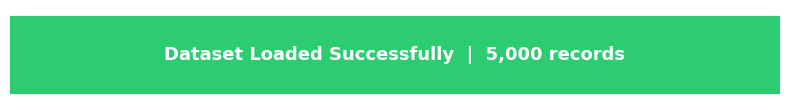

In [3]:
csv_path = "C:/Users/Dell/Downloads/IT_Career_Guidance_5000_Final.csv"
try:
    df = pd.read_csv(csv_path)
    status_msg = f"Dataset Loaded Successfully  |  {len(df):,} records"
    status_color = '#2ecc71'
except FileNotFoundError:
    df = None
    status_msg = "Error: Dataset not found at specified path"
    status_color = '#e74c3c'

fig, ax = plt.subplots(figsize=(8, 1.2))
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis('off')
bbox = FancyBboxPatch((0.01, 0.1), 0.98, 0.8, boxstyle='round,pad=0.05',
                       facecolor=status_color, edgecolor='white', linewidth=2)
ax.add_patch(bbox)
ax.text(0.5, 0.5, status_msg, ha='center', va='center',
        fontsize=13, fontweight='bold', color='white')
plt.tight_layout()
plt.show()

In [16]:
csv_path = "C:/Users/Dell/Downloads/IT_Career_Guidance_5000_Final.csv"
try:
    df = pd.read_csv(csv_path)
    print(f"Dataset loaded: {len(df):,} records")
except FileNotFoundError:
    print("Error: Dataset not found.")

Dataset loaded: 5,000 records


In [17]:
random.seed(42)
indices = df.index.tolist()
random.shuffle(indices)
split_idx  = int(len(indices) * 0.8)
train_df   = df.loc[indices[:split_idx]].copy()
test_df    = df.loc[indices[split_idx:]].copy()
print(f"Train: {len(train_df):,}  |  Test: {len(test_df):,}")

Train: 4,000  |  Test: 1,000


In [18]:
model = ITCareerAdvisorFinal()
model.fit(train_df)
print(f"Model trained on {len(model.classes)} career classes.")

Model trained on 30 career classes.


In [19]:
y_test_true, y_test_pred, latencies = [], [], []
top3_hits = 0
for _, r in test_df.iterrows():
    t0    = time.perf_counter()
    preds = model.predict_top_k(r['Skills'], r['Interests'], r['Strengths'], k=3)
    latencies.append(time.perf_counter() - t0)
    actual = r['Career_Recommendation'].lower().strip()
    y_test_true.append(actual)
    y_test_pred.append(preds[0][0])
    if actual in [p[0] for p in preds]:
        top3_hits += 1

def get_metrics(y_true, y_pred, labels):
    p_list, r_list = [], []
    for label in labels:
        tp = sum(1 for t, p in zip(y_true, y_pred) if t == label and p == label)
        fp = sum(1 for t, p in zip(y_true, y_pred) if t != label and p == label)
        fn = sum(1 for t, p in zip(y_true, y_pred) if t == label and p != label)
        p_list.append(tp / (tp + fp) if (tp + fp) > 0 else 0)
        r_list.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
    prec = sum(p_list) / len(labels)
    rec  = sum(r_list) / len(labels)
    f1   = 2 * (prec * rec) / (prec + rec) if (prec + rec) > 0 else 0
    return prec * 100, rec * 100, f1 * 100

train_hits = 0
for _, r in train_df.iterrows():
    p = model.predict_top_k(r['Skills'], r['Interests'], r['Strengths'], k=1)
    if r['Career_Recommendation'].lower().strip() == p[0][0]:
        train_hits += 1

train_acc      = (train_hits / len(train_df)) * 100
test_acc       = (sum(1 for t, p in zip(y_test_true, y_test_pred) if t == p) / len(test_df)) * 100
top3_acc       = (top3_hits / len(test_df)) * 100
acc_gap        = train_acc - test_acc
avg_latency_ms = (sum(latencies) / len(latencies)) * 1000
prec, rec, f1  = get_metrics(y_test_true, y_test_pred, model.classes)

print(f"Train Acc: {train_acc:.2f}%  |  Test Acc: {test_acc:.2f}%  |  Top-3: {top3_acc:.2f}%")
print(f"Precision: {prec:.2f}%  |  Recall: {rec:.2f}%  |  F1: {f1:.2f}%")
print(f"Acc Gap: {acc_gap:.2f}%  |  Latency: {avg_latency_ms:.4f} ms/pred")

Train Acc: 87.65%  |  Test Acc: 86.80%  |  Top-3: 99.80%
Precision: 87.10%  |  Recall: 86.91%  |  F1: 87.00%
Acc Gap: 0.85%  |  Latency: 0.6789 ms/pred


In [20]:
labels = model.classes
cm = np.zeros((len(labels), len(labels)), dtype=int)
for t, p in zip(y_test_true, y_test_pred):
    if t in labels and p in labels:
        cm[labels.index(t)][labels.index(p)] += 1

1. Grouped Bar Chart of Train Accuracy, Test Accuracy, Top 3 Accuracy, Precision, Recall, F1 Score

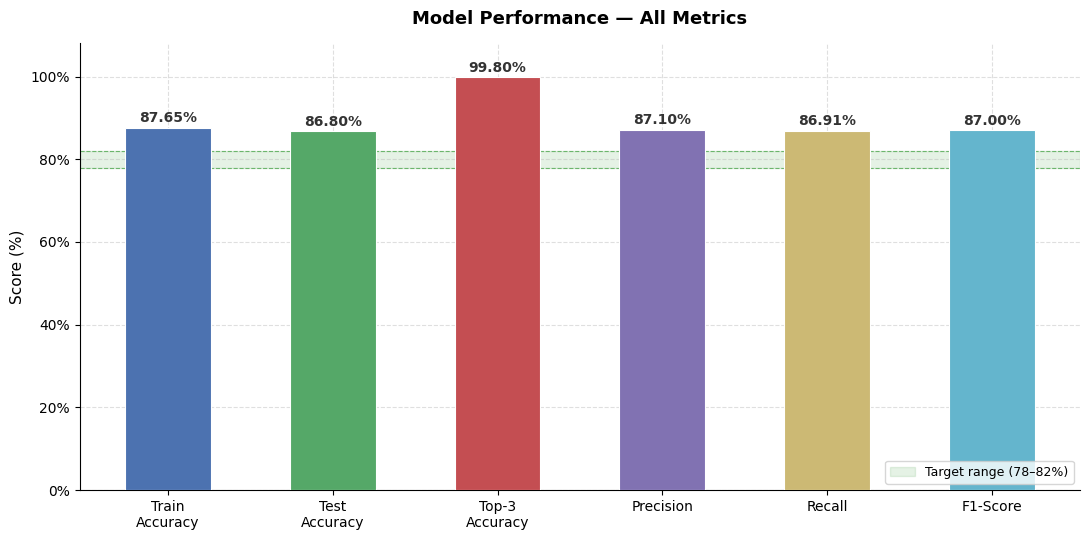

In [ ]:

metric_names  = ['Train\nAccuracy', 'Test\nAccuracy', 'Top-3\nAccuracy', 'Precision', 'Recall', 'F1-Score']
metric_values = [train_acc, test_acc, top3_acc, prec, rec, f1]
colors        = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974', '#64B5CD']

fig, ax = plt.subplots(figsize=(11, 5.5))

x     = np.arange(len(metric_names))
bars  = ax.bar(x, metric_values, width=0.52, color=colors,
               edgecolor='white', linewidth=0.8, zorder=3)


for bar, val in zip(bars, metric_values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.6,
        f'{val:.2f}%',
        ha='center', va='bottom',
        fontsize=10, fontweight='bold', color='#333333'
    )


ax.axhspan(78, 82, alpha=0.10, color='green', label='Target range (78–82%)', zorder=1)
ax.axhline(82, color='green', linewidth=0.8, linestyle='--', alpha=0.5, zorder=2)
ax.axhline(78, color='green', linewidth=0.8, linestyle='--', alpha=0.5, zorder=2)

ax.set_xticks(x)
ax.set_xticklabels(metric_names, fontsize=11)
ax.set_ylabel('Score (%)', fontsize=11)
ax.set_title('Model Performance — All Metrics', fontsize=13, fontweight='bold', pad=14)
ax.set_ylim(0, 108)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%g%%'))
ax.legend(fontsize=9, loc='lower right')
ax.tick_params(axis='both', labelsize=10)

plt.tight_layout()
plt.show()

2. Line Graph — Train vs Test + Gap 
Simulate progressive split ratios to show how accuracy evolves

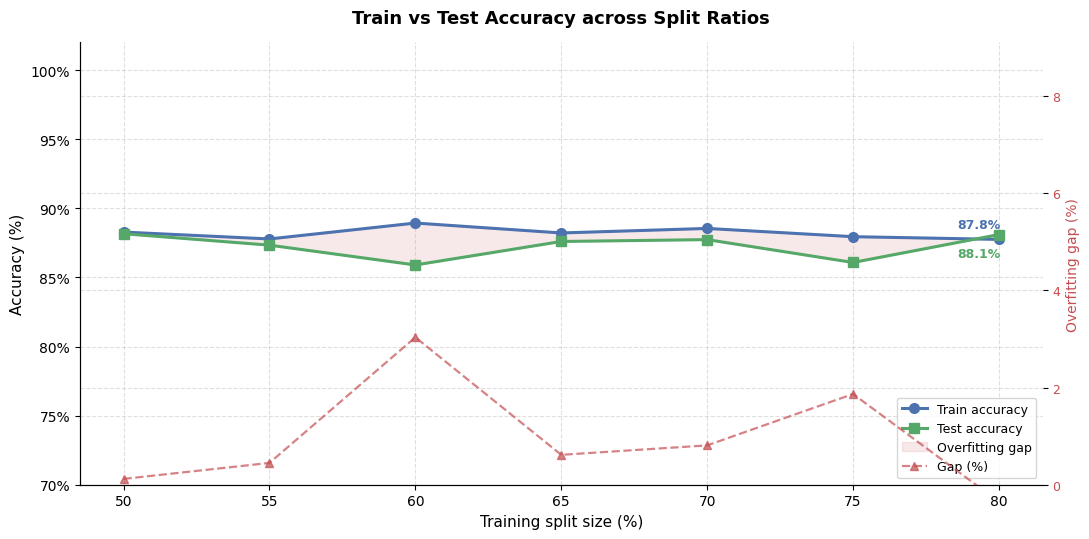

In [ ]:

split_ratios  = [0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80]
train_accs_   = []
test_accs_    = []

random.seed(42)
for ratio in split_ratios:
    random.shuffle(indices)
    s_idx   = int(len(indices) * ratio)
    tr_df   = df.loc[indices[:s_idx]].copy()
    te_df   = df.loc[indices[s_idx:]].copy()
    m_      = ITCareerAdvisorFinal()
    m_.fit(tr_df)
    tr_hits = sum(
        1 for _, r in tr_df.iterrows()
        if r['Career_Recommendation'].lower().strip() == m_.predict_top_k(
            r['Skills'], r['Interests'], r['Strengths'], k=1)[0][0]
    )
    te_true, te_pred = [], []
    for _, r in te_df.iterrows():
        te_true.append(r['Career_Recommendation'].lower().strip())
        te_pred.append(m_.predict_top_k(r['Skills'], r['Interests'], r['Strengths'], k=1)[0][0])
    train_accs_.append((tr_hits / len(tr_df)) * 100)
    test_accs_.append((sum(t == p for t, p in zip(te_true, te_pred)) / len(te_df)) * 100)

gap_ = [tr - te for tr, te in zip(train_accs_, test_accs_)]
split_pct = [int(r * 100) for r in split_ratios]

fig, ax1 = plt.subplots(figsize=(11, 5.5))

# Train line
ax1.plot(split_pct, train_accs_, marker='o', markersize=7, linewidth=2.2,
         color='#4C72B0', label='Train accuracy', zorder=3)
# Test line
ax1.plot(split_pct, test_accs_,  marker='s', markersize=7, linewidth=2.2,
         color='#55A868', label='Test accuracy', zorder=3)
# Shaded gap
ax1.fill_between(split_pct, train_accs_, test_accs_,
                 alpha=0.12, color='#C44E52', label='Overfitting gap')

# Annotate final point
ax1.annotate(f'{train_accs_[-1]:.1f}%',
             xy=(split_pct[-1], train_accs_[-1]),
             xytext=(-30, 8), textcoords='offset points',
             fontsize=9, color='#4C72B0', fontweight='bold')
ax1.annotate(f'{test_accs_[-1]:.1f}%',
             xy=(split_pct[-1], test_accs_[-1]),
             xytext=(-30, -16), textcoords='offset points',
             fontsize=9, color='#55A868', fontweight='bold')

# Secondary axis: gap
ax2 = ax1.twinx()
ax2.plot(split_pct, gap_, marker='^', markersize=6, linewidth=1.6,
         linestyle='--', color='#C44E52', label='Gap (%)', alpha=0.7)
ax2.set_ylabel('Overfitting gap (%)', fontsize=10, color='#C44E52')
ax2.tick_params(axis='y', labelcolor='#C44E52', labelsize=9)
ax2.spines['right'].set_color('#C44E52')
ax2.spines['top'].set_visible(False)
ax2.set_ylim(0, max(gap_) * 3)

ax1.set_xlabel('Training split size (%)', fontsize=11)
ax1.set_ylabel('Accuracy (%)', fontsize=11)
ax1.set_title('Train vs Test Accuracy across Split Ratios', fontsize=13,
              fontweight='bold', pad=14)
ax1.set_ylim(70, 102)
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('%g%%'))
ax1.tick_params(labelsize=10)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='lower right')

plt.tight_layout()
plt.show()

3. Per-class Recall horizontal bar chart

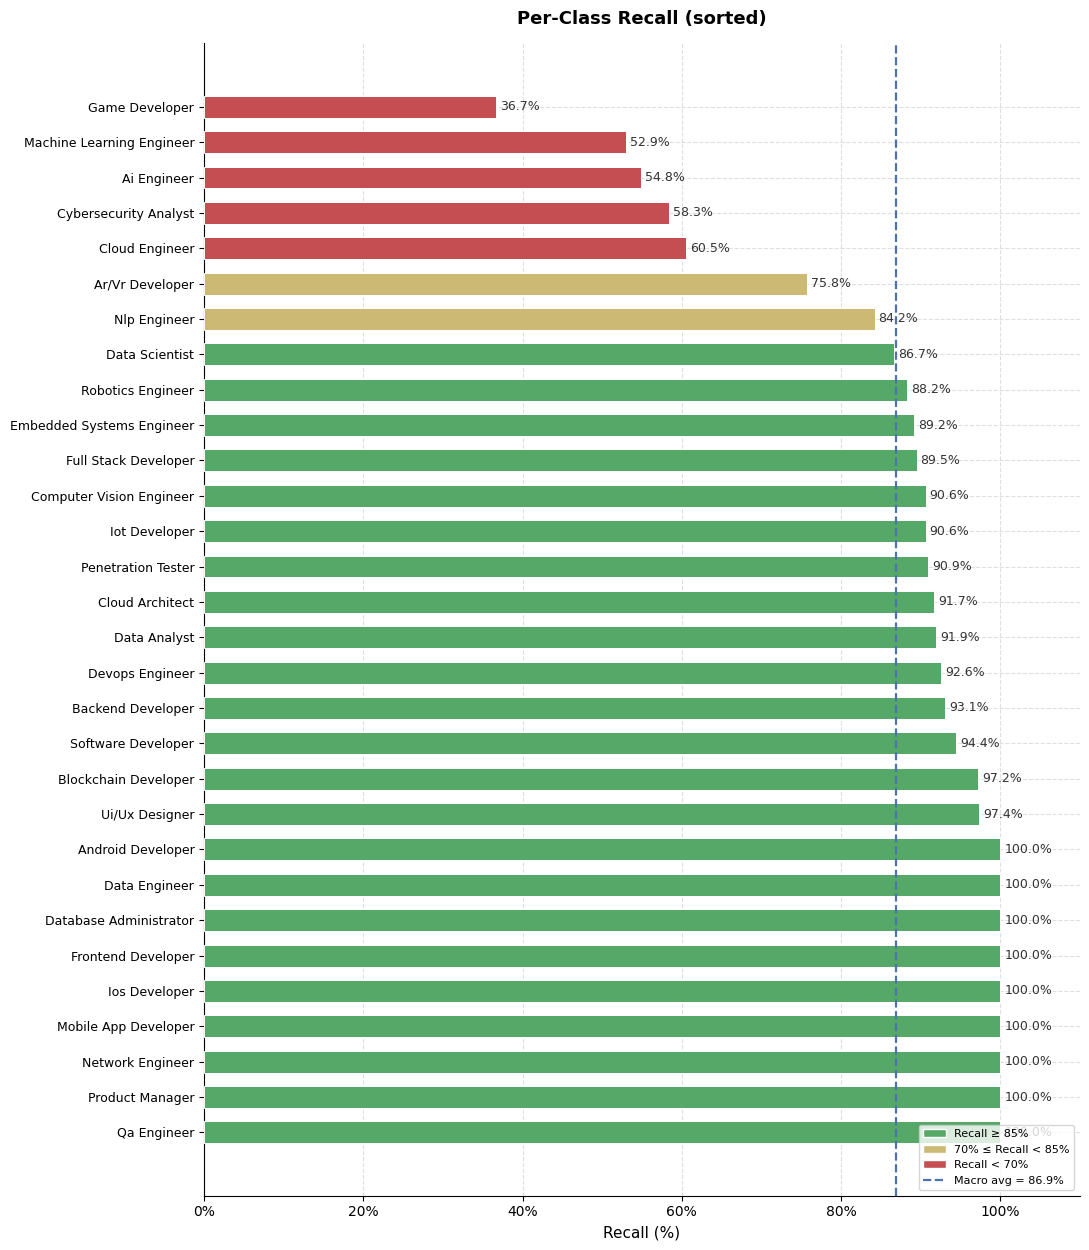

In [ ]:

class_recalls = []
for label in labels:
    tp = sum(1 for t, p in zip(y_test_true, y_test_pred) if t == label and p == label)
    fn = sum(1 for t, p in zip(y_test_true, y_test_pred) if t == label and p != label)
    class_recalls.append((tp / (tp + fn) * 100) if (tp + fn) > 0 else 0)

sorted_pairs = sorted(zip(class_recalls, labels), reverse=True)
sorted_vals  = [v for v, _ in sorted_pairs]
sorted_lbls  = [l.title() for _, l in sorted_pairs]

# Color bars: green if recall >= 85, amber if 70-85, red below 70
bar_colors = ['#55A868' if v >= 85 else ('#CCB974' if v >= 70 else '#C44E52')
              for v in sorted_vals]

fig, ax = plt.subplots(figsize=(11, max(6, len(labels) * 0.42)))

y_pos = np.arange(len(sorted_lbls))
hbars = ax.barh(y_pos, sorted_vals, height=0.62,
                color=bar_colors, edgecolor='white', linewidth=0.7, zorder=3)

# Value labels
for bar, val in zip(hbars, sorted_vals):
    ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', ha='left', fontsize=9, color='#333333')

# Average line
ax.axvline(rec, color='#4C72B0', linewidth=1.6, linestyle='--',
           label=f'Macro avg recall = {rec:.1f}%', zorder=4)

ax.set_yticks(y_pos)
ax.set_yticklabels(sorted_lbls, fontsize=9)
ax.set_xlabel('Recall (%)', fontsize=11)
ax.set_title('Per-Class Recall (sorted)', fontsize=13, fontweight='bold', pad=14)
ax.set_xlim(0, 110)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%g%%'))
ax.legend(fontsize=9)
ax.tick_params(axis='x', labelsize=10)

# Legend for colors
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#55A868', edgecolor='white', label='Recall ≥ 85%'),
    Patch(facecolor='#CCB974', edgecolor='white', label='70% ≤ Recall < 85%'),
    Patch(facecolor='#C44E52', edgecolor='white', label='Recall < 70%'),
]
ax.legend(handles=legend_elements +
          [plt.Line2D([0],[0], color='#4C72B0', linewidth=1.6,
                      linestyle='--', label=f'Macro avg = {rec:.1f}%')],
          fontsize=8, loc='lower right')

plt.tight_layout()
plt.show()

4. Confusion Matrix Heatmap

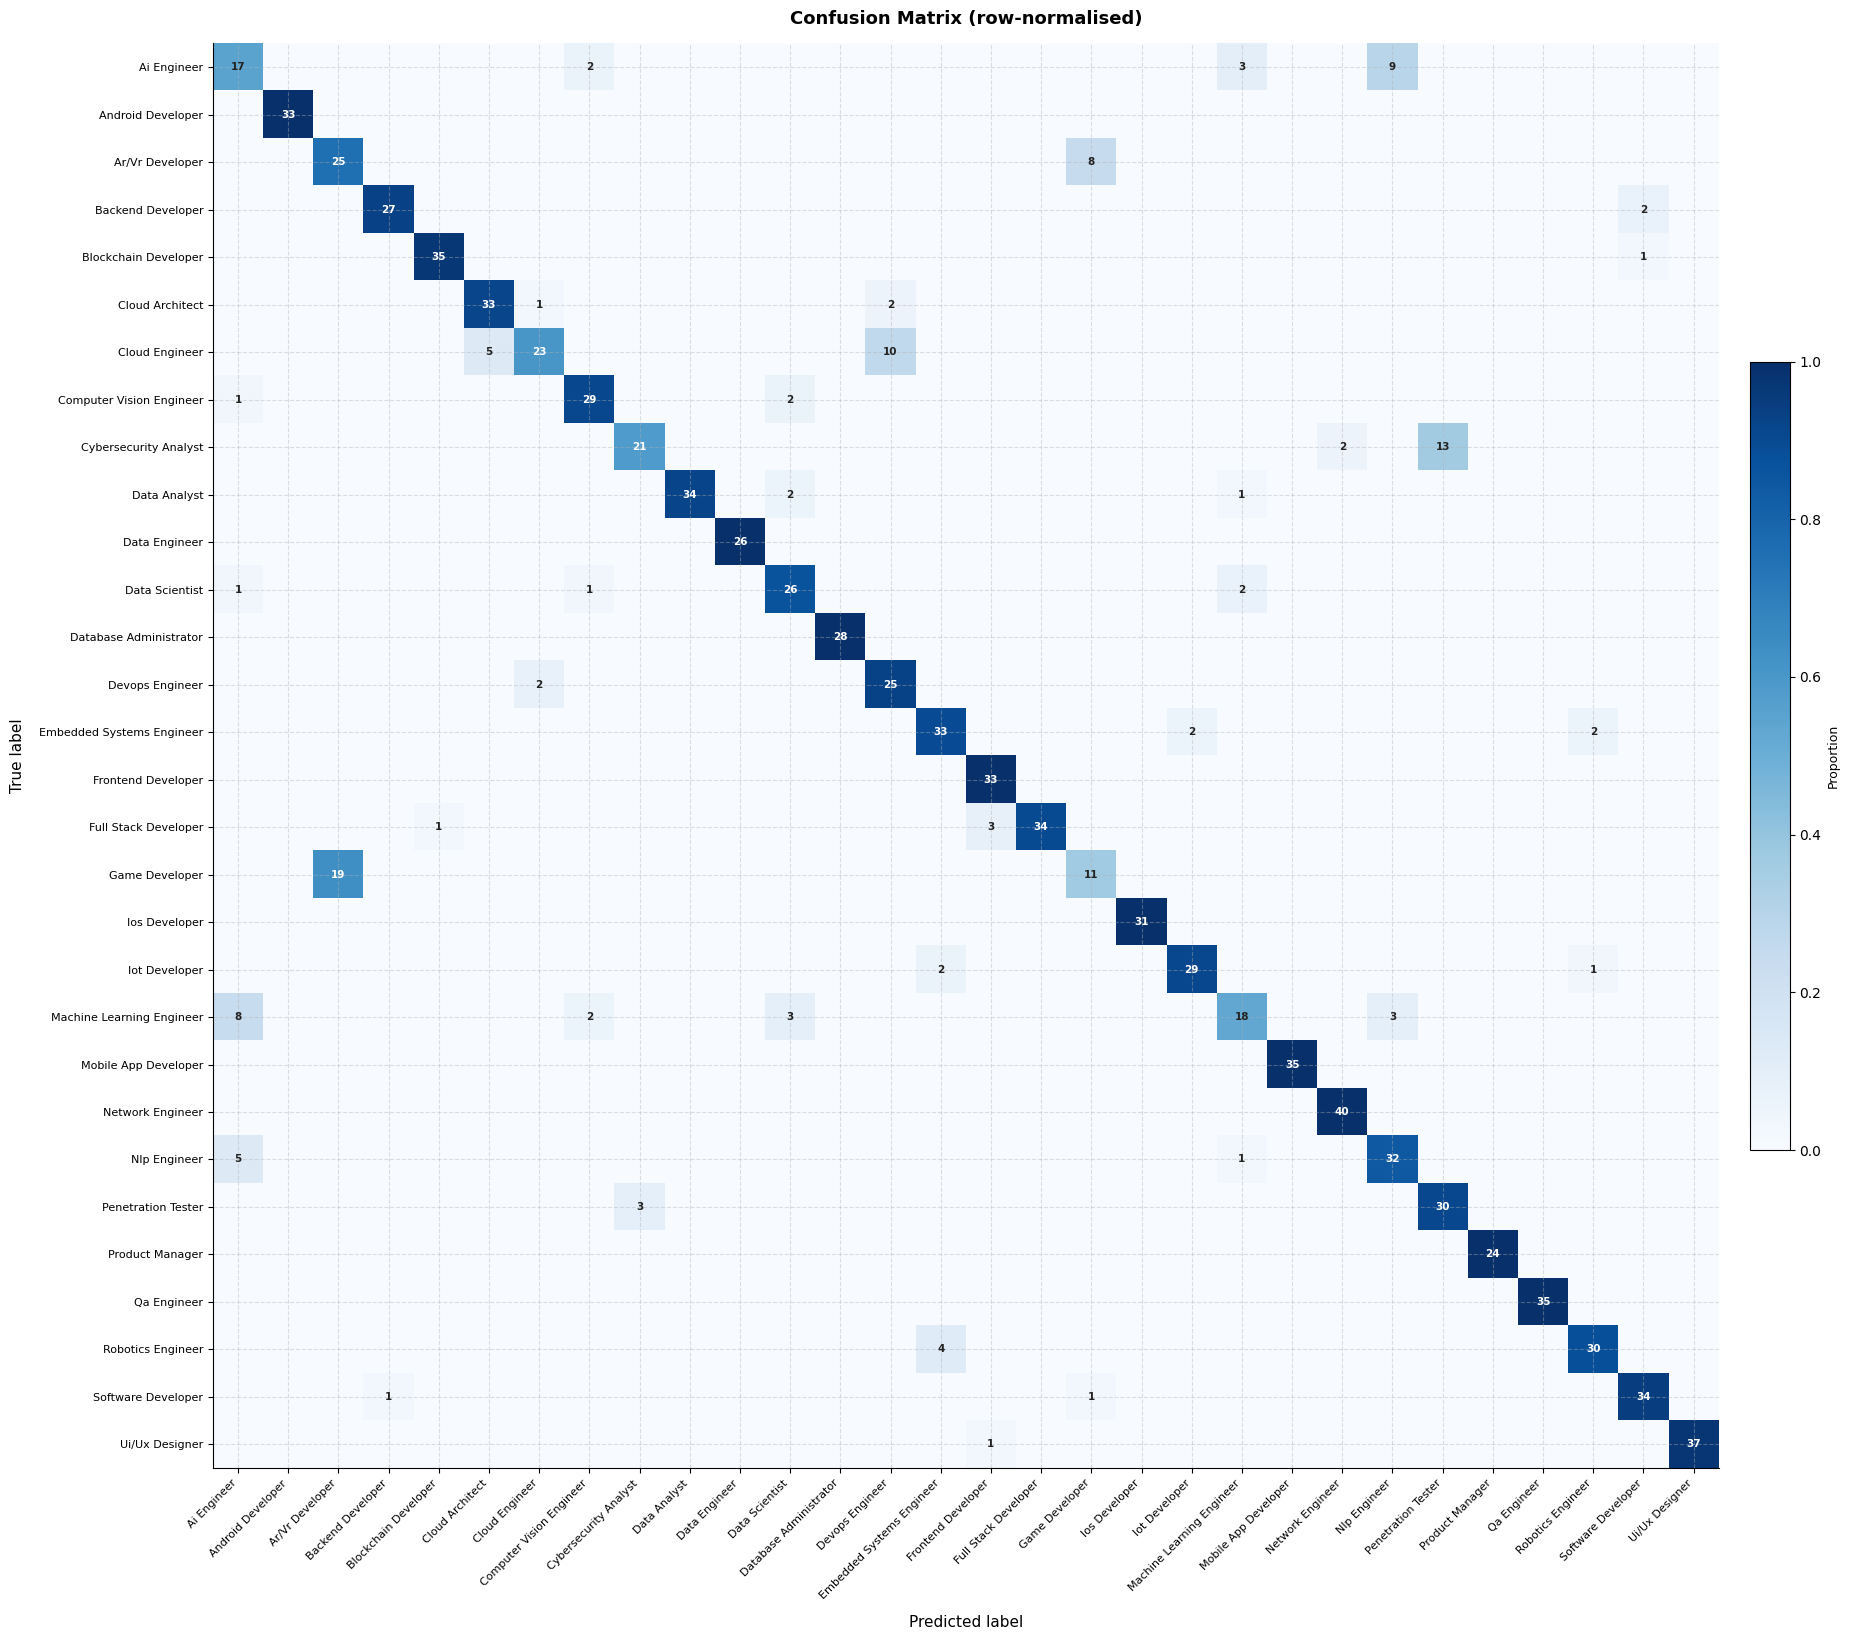

In [ ]:

n          = len(labels)
row_sums   = cm.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1
cm_norm    = cm.astype(float) / row_sums   
tick_lbls  = [l.title() for l in labels]

fig, ax = plt.subplots(figsize=(max(13, n * 0.62), max(11, n * 0.55)))

im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1, aspect='auto')


for i in range(n):
    for j in range(n):
        raw  = cm[i, j]
        if raw > 0:
            clr = 'white' if cm_norm[i, j] > 0.55 else '#222222'
            ax.text(j, i, str(raw), ha='center', va='center',
                    fontsize=7.5, color=clr, fontweight='bold')

ax.set_xticks(range(n))
ax.set_xticklabels(tick_lbls, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(n))
ax.set_yticklabels(tick_lbls, fontsize=8)
ax.set_xlabel('Predicted label', fontsize=11, labelpad=10)
ax.set_ylabel('True label',      fontsize=11, labelpad=10)
ax.set_title('Confusion Matrix (row-normalised)', fontsize=13,
             fontweight='bold', pad=14)

cbar = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
cbar.set_label('Proportion', fontsize=9)

plt.tight_layout()
plt.show()

5. Strategic Career Alignment & Growth Mapping


════════════════════════════════════════════════════════════════════════════════
   IDENTIFIED TALENT PROFILE
════════════════════════════════════════════════════════════════════════════════
   SKILLS    : HTML,AWS,JS,REACT
   INTERESTS : Data,Cloud
   STRENGTHS : Creative
────────────────────────────────────────────────────────────────────────────────
  TOP 3 CAREER RECOMMENDATIONS & PROGRESSION
────────────────────────────────────────────────────────────────────────────────
  1. Full Stack Developer      ➔   Next Goal: Senior Full Stack Developer
  2. Frontend Developer        ➔   Next Goal: Full Stack Developer
  3. Iot Developer             ➔   Next Goal: Senior Iot Developer
════════════════════════════════════════════════════════════════════════════════



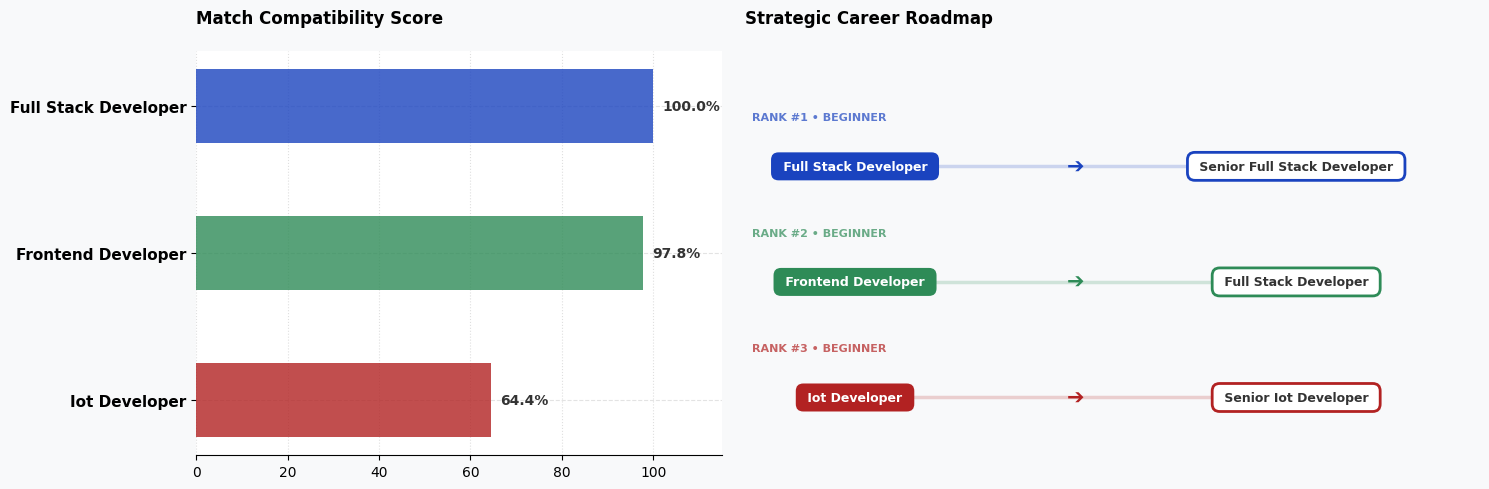

In [ ]:

s  = input("Skills    : ")
i  = input("Interests : ")
st = input("Strengths : ")


results = model.predict_top_k(s, i, st, k=3)

raw_scores  = [sc for _, sc in results]
hi          = max(raw_scores) if max(raw_scores) != 0 else 1
norm_vals   = [(sc / hi) * 100 for sc in raw_scores] 
career_lbls = [name.title() for name, _ in results]
rank_colors = ['#1A43BF', '#2E8B57', '#B22222'] 


print("\n" + "═"*80)
print(f"   IDENTIFIED TALENT PROFILE")
print("═"*80)
print(f"   SKILLS    : {s.upper()}")
print(f"   INTERESTS : {i.title()}")
print(f"   STRENGTHS : {st.title()}")
print("─"*80)
print(f"  TOP 3 CAREER RECOMMENDATIONS & PROGRESSION")
print("─"*80)

for idx, (name, _) in enumerate(results):
    nxt = model.dag.get(name, 'Senior ' + name.title())
    print(f"  {idx+1}. {name.title():<25} ➔   Next Goal: {nxt}")

print("═"*80 + "\n")


fig, (ax_bar, ax_path) = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={'width_ratios': [1, 1.4]})
fig.patch.set_facecolor('#F8F9FA') 


y_pos = np.arange(len(career_lbls))
bars = ax_bar.barh(y_pos, norm_vals, height=0.5, color=rank_colors, alpha=0.8, zorder=3)

for bar, val in zip(bars, norm_vals):
    ax_bar.text(val + 2, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', 
                va='center', fontweight='bold', color='#333333', fontsize=10)

ax_bar.set_yticks(y_pos)
ax_bar.set_yticklabels(career_lbls, fontsize=11, fontweight='bold')
ax_bar.set_title('Match Compatibility Score', fontsize=12, fontweight='black', loc='left', pad=20)
ax_bar.set_xlim(0, 115)
ax_bar.invert_yaxis()
ax_bar.spines['left'].set_visible(False)
ax_bar.grid(axis='x', linestyle=':', alpha=0.4)


ax_path.set_xlim(0, 10); ax_path.set_ylim(-0.5, 3); ax_path.axis('off')
ax_path.set_title('Strategic Career Roadmap', fontsize=12, fontweight='black', loc='left', pad=20)

for idx, (name, _) in enumerate(results):
    y = 2 - idx 
    clr = rank_colors[idx]
    nxt = model.dag.get(name, 'Senior ' + name.title())
    tier = 'Advanced' if any(w in name.lower() for w in ['senior', 'architect', 'engineer']) else 'Beginner'

 
    ax_path.plot([1.5, 7.5], [y, y], color=clr, lw=2.5, alpha=0.2, zorder=1)

    
    ax_path.text(1.5, y, f" {name.title()} ", va='center', ha='center', fontsize=9, 
                 fontweight='bold', color='white', zorder=5,
                 bbox=dict(facecolor=clr, edgecolor='none', boxstyle='round,pad=0.6'))

    
    ax_path.text(4.5, y, "➔", va='center', ha='center', fontsize=15, color=clr, fontweight='bold', zorder=6)

 
    ax_path.text(7.5, y, f" {nxt} ", va='center', ha='center', fontsize=9, 
                 fontweight='bold', color='#333333', zorder=5,
                 bbox=dict(facecolor='white', edgecolor=clr, boxstyle='round,pad=0.6', lw=2))

   
    ax_path.text(0.1, y + 0.4, f"RANK #{idx+1} • {tier.upper()}", fontsize=8, 
                 fontweight='black', color=clr, alpha=0.7)

plt.tight_layout()
plt.show()